# Esame Laboratorio di Programmazione II - 27/06/2025


In [ ]:
#LIBRERIE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

## Esercizio 1

Crea un array NumPy con i prezzi (in euro) di 5 libri: **14.99, 22.50, 9.75, 18.00, 31.20, 12.80, 24.90, 8.40, 19.99, 27.30**

1. Calcola il prezzo medio dei libri
2. Seleziona i libri con un prezzo maggiore della media.
3. Crea un nuovo array che applica uno sconto del 10% solo ai libri che costano più della media.

In [ ]:
#1
a = np.array([14.99, 22.50, 9.75, 18.00, 31.20, 12.80, 24.90, 8.40, 19.99, 27.30])
prezzo_medio = np.mean(a)
print("Prezzo medio dei libri: ", prezzo_medio)
#2
selez = a[a>prezzo_medio]
#3
sconto = np.where(a>prezzo_medio, a*0.9, a)
print("Array scontato: ", sconto)

Prezzo medio dei libri:  18.983000000000004
Array scontato:  [14.99  20.25   9.75  18.    28.08  12.8   22.41   8.4   17.991 24.57 ]


## Esercizio 2

Simula 1000 lanci di una moneta che ad ogni lancio ha il doppio di probabilità di risultare croce invece che testa. Ogni lancio è rappresentato da 1 (testa) o 0 (croce).

1. Crea un array NumPy contenente i risultati.
2. Calcola la proporzione di teste dopo ogni 50 lanci cumulativi.
3. Crea un grafico della proporzione cumulativa nel tempo (dopo 50 lanci, dopo 100, dopo 150,...).

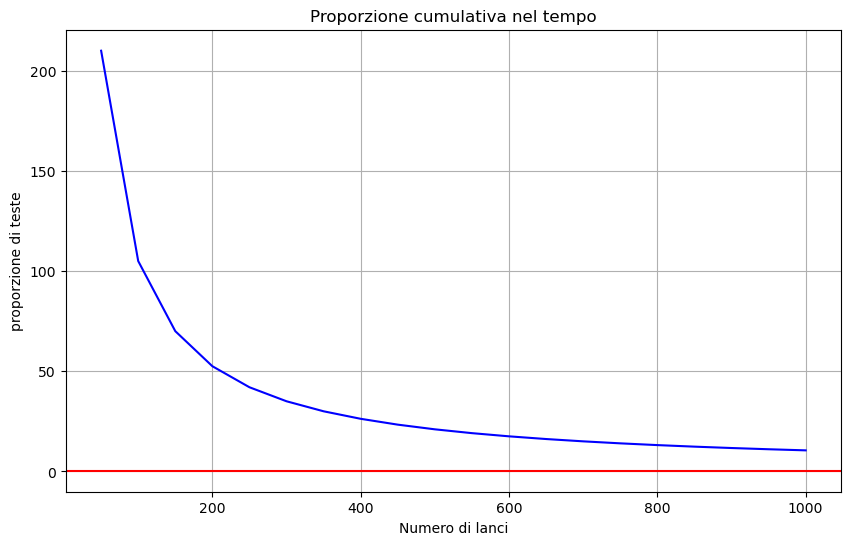

In [8]:
#1
risultati = np.random.choice([1,0], size = 1000, p=[1/3, 2/3])
#2
range = np.arange(50,1001, 50)
proporzioni = []
for n in range:
    lanci_parz = range[:n]
    num_teste = np.sum(lanci_parz)
    proporz_teste = num_teste/n
    proporzioni.append(proporz_teste)
#3
plt.figure(figsize=(10,6))
plt.plot(range, proporzioni, color="blue", label="Proporzione osservata")
plt.axhline(y = 1/3, color = "red", label="Probabilità teorica")
plt.title("Proporzione cumulativa nel tempo")
plt.xlabel("Numero di lanci")
plt.ylabel("proporzione di teste")
plt.grid(True)
plt.show()

## Esercizio 3

Crea una funzione di nome **mat_normalizzata** che prende come input una matrice e ritorna la matrice normalizzata.

La funzione deve quindi:
1. Calcolare la media e la deviazione standard della matrice.
2. Normalizzare la matrice sottraendo la media e dividendo per la deviazione standard.

Testa La funzione con un array NumPy 6x10 con numeri campionati da una distribuzione normale (media=5, std=2).

In [10]:
def mat_normalizzata(matrice):
    media = np.mean(matrice)
    dev_stand = np.std(matrice)

    matrice_norm= (matrice -media)/dev_stand
    return(matrice_norm)

#test
matrice_test = np.random.normal(loc=5, scale=2, size=(6,10))
print(f"Esempio con una la matrice {matrice_test}, la sua matrice normalizaìzata è:\n ")
print(mat_normalizzata(matrice_test))


Esempio con una la matrice [[2.44032513 6.56798919 6.84358132 2.33392477 6.46875074 4.79156115
  4.85461479 7.41340346 5.21509845 4.85998154]
 [4.84398795 7.25694416 2.52892828 5.33816767 6.25833377 4.19660311
  7.1561543  4.46932626 0.11790055 5.85696331]
 [3.38758371 4.833223   0.61228549 7.35482281 4.71048505 4.61609195
  4.86758969 3.66487818 6.21036034 6.26763617]
 [3.77688012 1.25701395 5.60547401 5.36184829 3.62039766 1.95438238
  2.64743397 1.54427545 4.00473398 7.46179326]
 [9.12203138 8.57902169 0.94273895 7.71915855 6.87588286 9.5693595
  4.44878023 5.81471462 5.34483703 3.98303228]
 [6.9135305  6.26834768 5.72391574 5.2548753  5.70008565 6.15846968
  4.73851938 4.21790441 4.90980713 3.34077675]], la sua matrice normalizaìzata è:
 
[[-1.25693652  0.7806126   0.91665384 -1.3094592   0.73162528 -0.09629001
  -0.06516468  1.19793656  0.11278177 -0.06251548]
 [-0.07041044  1.12070317 -1.21319913  0.17353274  0.62775663 -0.38998063
   1.07095002 -0.25535562 -2.40336078  0.4296271

## Esercizio 4

Utilizza il dataset `books.csv`.

1. **Crea una nuova colonna** chiamata `engagement_score`, definita come:

   $$
   \texttt{engagement\_score} = \texttt{average\_rating} \times \log_{10}(1 + \texttt{ratings\_count})
   $$

   *(Un indicatore che tiene conto sia della qualità (valutazione media), sia della quantità di voti. Il logaritmo serve ad attenuare l'effetto dei libri estremamente popolari.)*

2. Trova il **libro con il valore massimo** di `engagement_score`.

3. **Filtra i libri** con una valutazione media (`average_rating`) **maggiore di 4.5**.

4. **Crea un grafico a barre** con i 10 libri con il valore più alto di `engagement_score`.

5. **Crea un grafico a linee** della `average_rating`, ordinando i libri per `ratings_count` crescente.


Il libro con engagement_score massimo:  title               Harry Potter and the Sorcerer's Stone
average_rating                                       4.47
ratings_count                                     7000000
engagement_score                                70.453551
Name: 4, dtype: object
Libri filtrati:
                      title  average_rating  ratings_count  engagement_score
10     La Divina Commedia            4.75           1500         34.740962
12     Il Nome della Rosa            4.55         150000         54.228707
13  Saggio sulla Lucidità            4.60           8000         41.341680
14          Poesie Scelte            4.80             50         18.872763
Primi 10 libri con engagement maggiore:                                      title  average_rating  ratings_count  \
4   Harry Potter and the Sorcerer's Stone            4.47        7000000   
1                   To Kill a Mockingbird            4.27        4500000   
3                              The Hobbit  

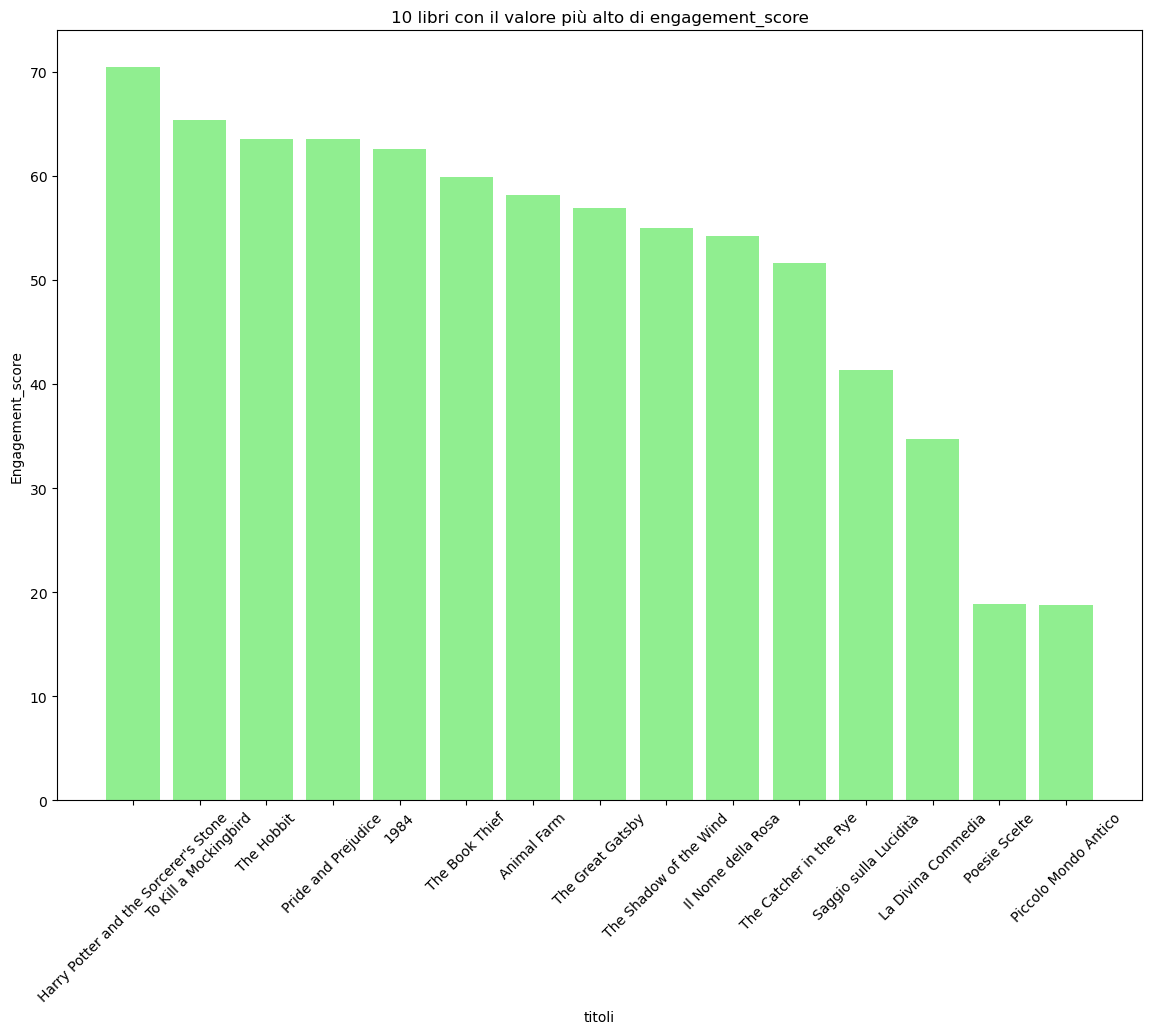

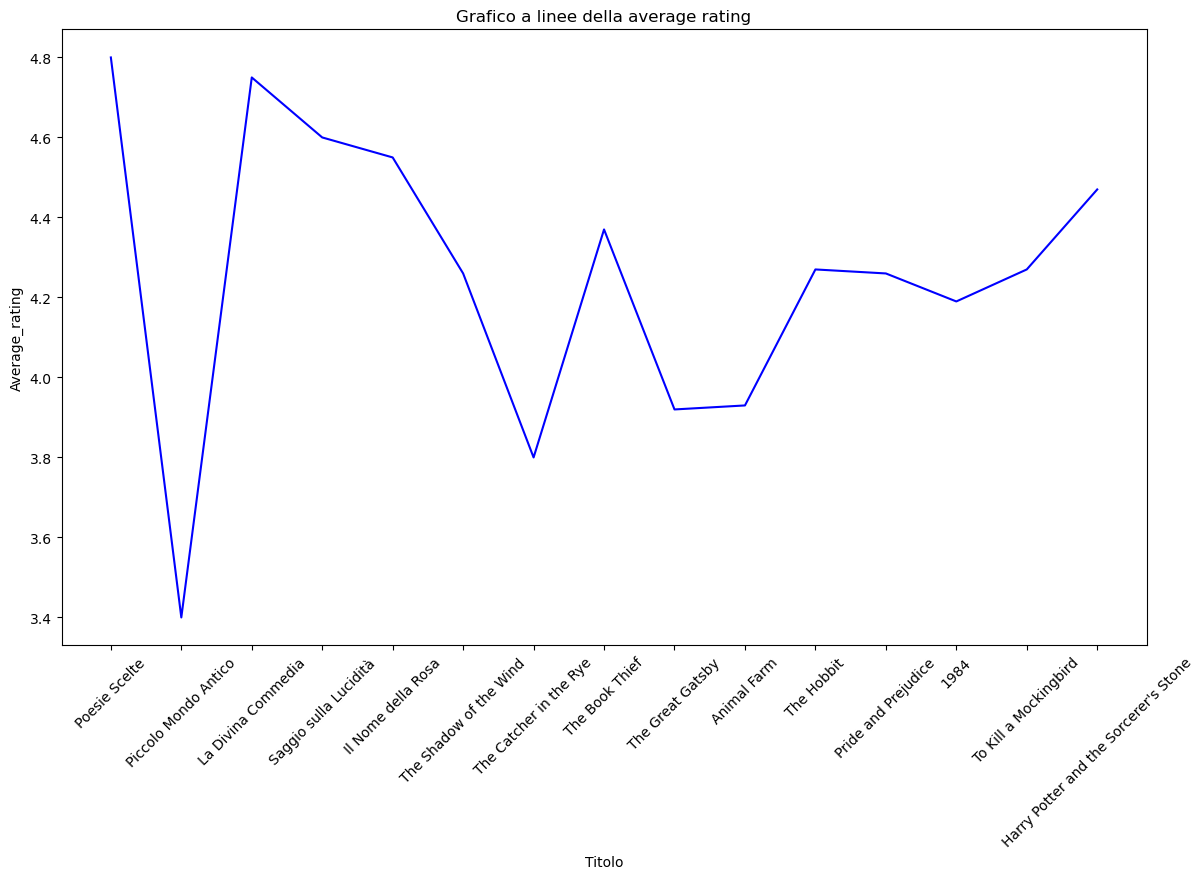

In [33]:
df = pd.read_csv("books.csv")
#1
df["engagement_score"] = df["average_rating"]*(np.log(1+ df["ratings_count"]))
df.head()
#2
indice_max = df["engagement_score"].idxmax()
libro_top = df.loc[indice_max]
print("Il libro con engagement_score massimo: ", libro_top)
#3
libri_filtrati = df[df["average_rating"] > 4.5]
print("Libri filtrati:\n ", libri_filtrati)
#4
df_ordinato = df.sort_values(by="engagement_score", ascending=False)
print("Primi 10 libri con engagement maggiore: ", df_ordinato.head(10))

plt.figure(figsize=(14,10))
plt.bar(df_ordinato["title"], df_ordinato["engagement_score"], color="lightgreen")
plt.title("10 libri con il valore più alto di engagement_score")
plt.xlabel("titoli")
plt.ylabel("Engagement_score")
plt.xticks(rotation=45)
plt.show()
#5
df_ordinato2 = df.sort_values(by="ratings_count", ascending = True)
plt.figure(figsize=(14,8))
plt.plot(df_ordinato2["title"], df_ordinato2["average_rating"], color="blue")
plt.xlabel("Titolo")
plt.ylabel("Average_rating")
plt.title("Grafico a linee della average rating")
plt.xticks(rotation=45)
plt.show()

## Esercizio 5
Utilizza il dataset `adult.csv`.
Contiene informazioni demografiche su adulti negli Stati Uniti. Le colonne rilevanti sono:
- `age`: età (integer)
- `workclass`, `education`, `marital-status`, `occupation`, `race`, `sex`
- `hours-per-week`: ore lavorate a settimana
- `income`: `>50K` o `<=50K` (target)

1. Quante **righe e colonne** ha il dataset?
2. Quanti **valori mancanti** ci sono per colonna?
3. **Sostituisci i valori mancanti** nelle colonne categoriche (workclass, occupation, native-country) con il valore più frequente (la moda).
4. Calcola l’**età media** (`age`) per sesso (`sex`)
5. Trova la % di persone che guadagnano **>50K** per sesso.
7. Crea una **colonna `age_group`** raggruppando le età in fasce: `'<30'`, `'30-50'`, `'>50'`.
8. **Crea**:
   - un grafico **a barre** con % di reddito `>50K` per fascia di età.
   - un **boxplot** delle ore lavorate (`hours-per-week`) per gruppo reddito (<=50, >50).


Numero righe e colonne dataset:  (20, 10)
Età media divisa per sesso:  sex
Female    35.166667
Male      40.857143
Name: age, dtype: float64
Percentuale di persone che guadagnano >50k per sesso sex
Female    33.333333
Male      35.714286
Name: guadagno, dtype: float64


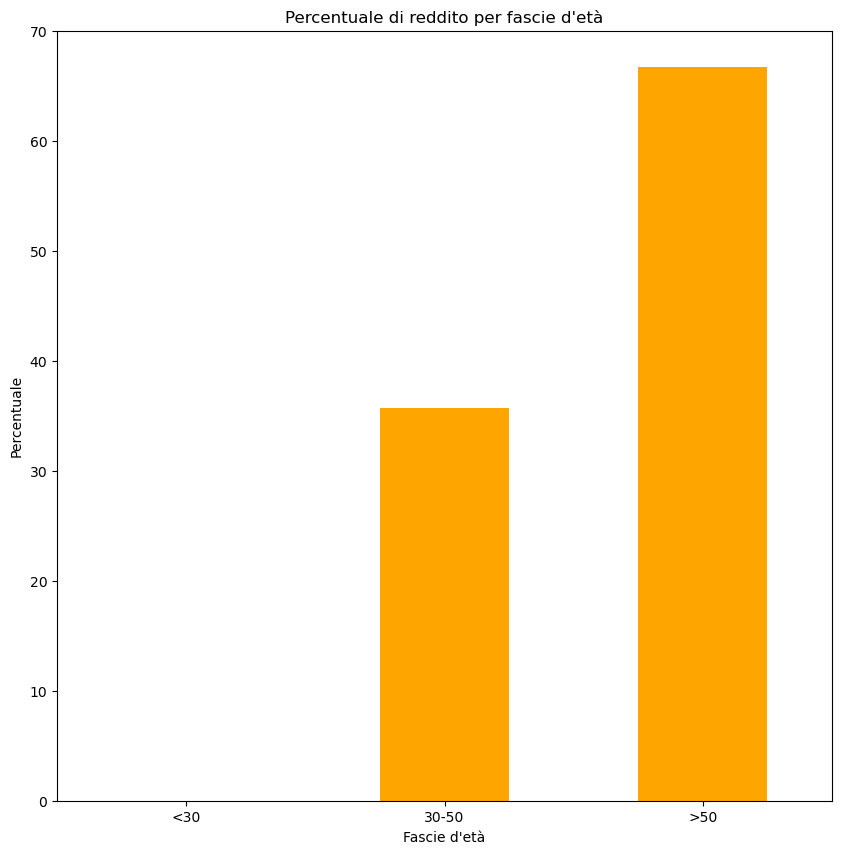

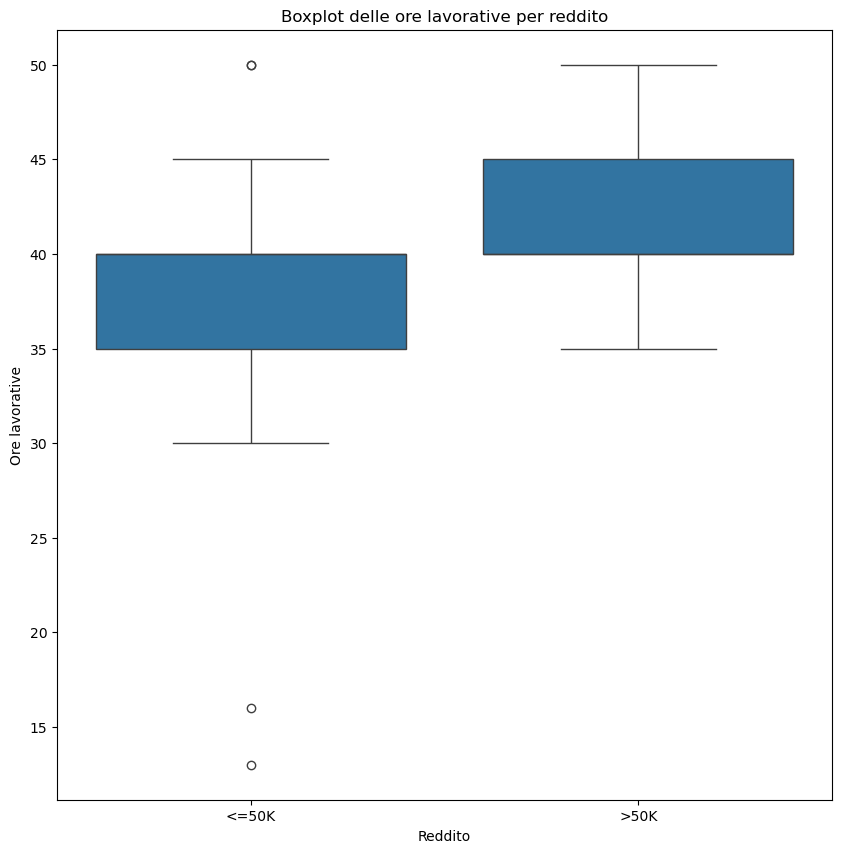

In [ ]:
df = pd.read_csv("adult.csv")
#1
dimensioni = df.shape
print("Numero righe e colonne dataset: ", dimensioni)
#2
val_manc = df.isnull().sum()
#3
val1 = df["workclass"].mode()[0]
val2 = df["occupation"].mode()[0]
val3 = df["native-country"].mode()[0]
df["workclass"].fillna(val1)
df["occupation"].fillna(val2)
df["native-country"].fillna(val3)
#4
mediaeta_sesso = df.groupby("sex")["age"].mean()
print("Età media divisa per sesso: ", mediaeta_sesso)
#5
df["guadagno"] = df["income"]==(">50K")
percentuale=df.groupby("sex")["guadagno"].mean()*100
print("Percentuale di persone che guadagnano >50k per sesso", percentuale)
#6
limiti = [0,29,50,120]
nomi = ["<30", "30-50", ">50"]
df["age_group"]=pd.cut(df["age"], bins=limiti, labels = nomi)
#7
perc_redd = df.groupby("age_group")["guadagno"].mean()*100
plt.figure(figsize=(10,10))
perc_redd.plot(kind="bar", color="orange")
plt.title("Percentuale di reddito per fascie d'età")
plt.xlabel("Fascie d'età")
plt.ylabel("Percentuale")
plt.xticks(rotation=0)
plt.show()
#8
plt.figure(figsize=(10,10))
sns.boxplot(data = df, x="income", y="hours-per-week")
plt.xlabel("Reddito")
plt.ylabel("Ore lavorative")
plt.title("Boxplot delle ore lavorative per reddito")
plt.show()

## Esercizio 6

Genera due array:

`x = np.linspace(0, 5, 80)`  
`y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)`

1. Usa `scipy.optimize.curve_fit` per stimare i parametri della retta.
2. Plotta i punti originali e la retta ottenuta.
3. Calcola MAE e RMSE tra i valori reali e quelli stimati.

Coefficiente angolare : 2.4372183822772717, intercetta : 1.4520246326099981


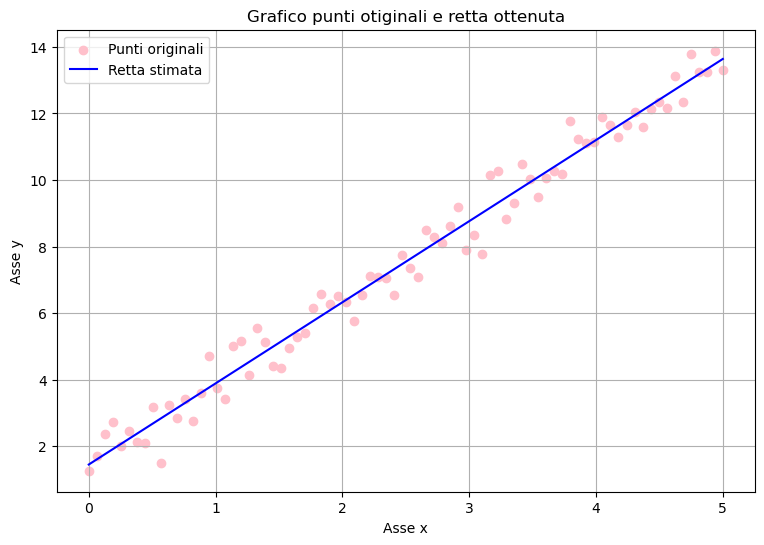

MAE = 0.42088845734466673, RMSE = 0.520351136975601


In [71]:
x = np.linspace(0, 5, 80)
y = 2.5 * x + 1.2 + np.random.normal(0, 0.5, 80)
#1
def modello_retta(x, m, q):
    return (m*x +q)
parametri_stimati, _ = curve_fit(modello_retta, x, y)
m_stimato, q_stimato = parametri_stimati
print(f"Coefficiente angolare : {m_stimato}, intercetta : {q_stimato}")
#2
y_stimato = modello_retta(x, m_stimato, q_stimato)
plt.figure(figsize=(9,6))
plt.scatter(x, y, color="pink", label ="Punti originali")
plt.plot(x, y_stimato, color="blue", label="Retta stimata")
plt.title("Grafico punti otiginali e retta ottenuta")
plt.xlabel("Asse x")
plt.ylabel("Asse y")
plt.legend()
plt.grid(True)
plt.show()
#3
mae = mean_absolute_error(y, y_stimato)
rmse = root_mean_squared_error(y, y_stimato)
print(f"MAE = {mae}, RMSE = {rmse}")